# Exploratory Data Analysis (EDA)
## Hybrid Machine Learning Framework for Chronic Kidney Disease Prediction

**Dataset:** UCI Chronic Kidney Disease Dataset  
**Records:** 400  
**Columns:** 25  
**Target:** `class` → `ckd` / `notckd`

### EDA Objectives
1. Descriptive statistics
2. Target/class distribution
3. Important feature distributions
4. Correlation analysis
5. Relevant visualizations
6. Observations and inferences from the EDA


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load the processed dataset
file_path = Path(
    r"C:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Hybrid_ML_CKD_Prediction\dataset\processed\chronic_kidney_disease_processed.csv"
)
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,...,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


## 1. Dataset Overview

The processed dataset contains **400 patient records and 25 columns**. The first 24 columns are input features and `class` is the target variable.

In [5]:
# Dataset information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Total missing values:", int(df.isna().sum().sum()))

print("\nData types:")
display(df.dtypes)

print("\nDuplicate rows:", df.duplicated().sum())


Rows: 400
Columns: 25
Total missing values: 0

Data types:


age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc          str
pc           str
pcc          str
ba           str
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn          str
dm           str
cad          str
appet        str
pe           str
ane          str
class        str
dtype: object


Duplicate rows: 0


## 2. Descriptive Statistics

Descriptive statistics help understand the central tendency, spread, minimum, maximum and quartiles of numerical variables.

In [6]:
# Descriptive statistics for numerical features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,400.0,51.562500,16.982996,2.000,42.000,55.00,64.000,90.000
bp,400.0,76.575000,13.489785,50.000,70.000,80.00,80.000,180.000
sg,400.0,1.017712,0.005434,1.005,1.015,1.02,1.020,1.025
al,400.0,0.900000,1.313130,0.000,0.000,0.00,2.000,5.000
su,400.0,0.395000,1.040038,0.000,0.000,0.00,0.000,5.000
bgr,400.0,145.062500,75.260774,22.000,101.000,121.00,150.000,490.000
bu,400.0,56.693000,49.395258,1.500,27.000,42.00,61.750,391.000
sc,400.0,2.997125,5.628886,0.400,0.900,1.30,2.725,76.000
sod,400.0,137.631250,9.206332,4.500,135.000,138.00,141.000,163.000
pot,400.0,4.577250,2.821357,2.500,4.000,4.40,4.800,47.000


### Interpretation
The table above gives the count, mean, standard deviation, minimum, quartiles and maximum for each numerical feature. The variables have different ranges, which is important when selecting models that are sensitive to feature scale.

## 3. Target / Class Distribution

The target variable represents whether the patient belongs to the **CKD** or **Not CKD** class.

,Count,Percentage
class,,
ckd,250,62.5
notckd,150,37.5


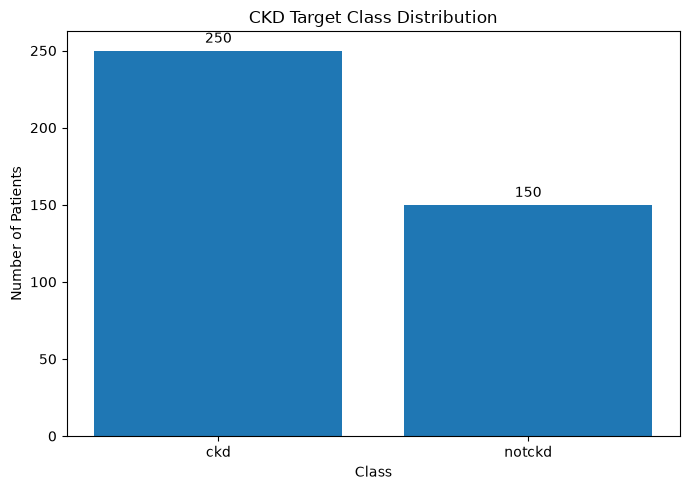

In [7]:
# Class counts and percentages
class_counts = df["class"].value_counts()
class_percent = df["class"].value_counts(normalize=True).mul(100).round(2)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

display(class_distribution)

# Bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(class_counts.index, class_counts.values)
plt.title("CKD Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

for bar, value in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 3, str(value),
             ha="center", va="bottom")

plt.tight_layout()
plt.show()


### Observation
- **CKD:** 250 records (62.5%)
- **Not CKD:** 150 records (37.5%)
- The classes are not perfectly balanced, so class-wise evaluation metrics such as precision, recall and F1-score should be considered along with accuracy.

## 4. Important Numerical Feature Distributions

The following features are visualized because they are useful clinical/laboratory attributes in the dataset:

- `age`
- `bp` — blood pressure
- `bgr` — blood glucose random
- `bu` — blood urea
- `sc` — serum creatinine
- `hemo` — hemoglobin


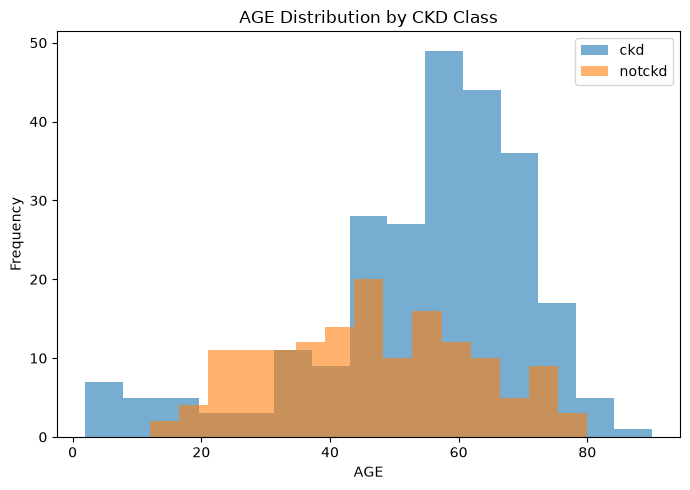

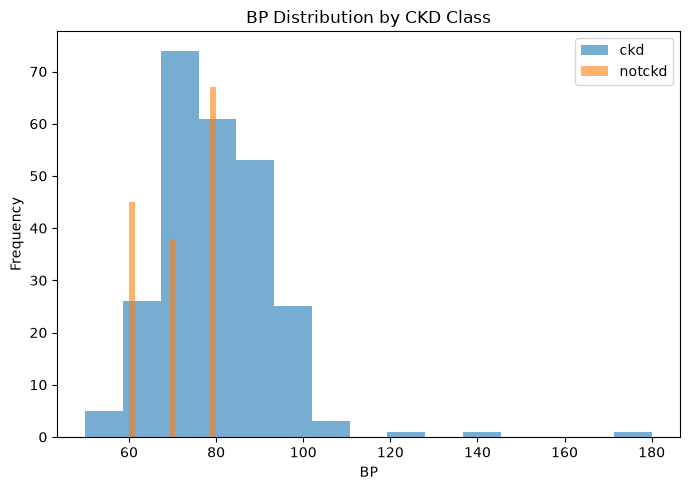

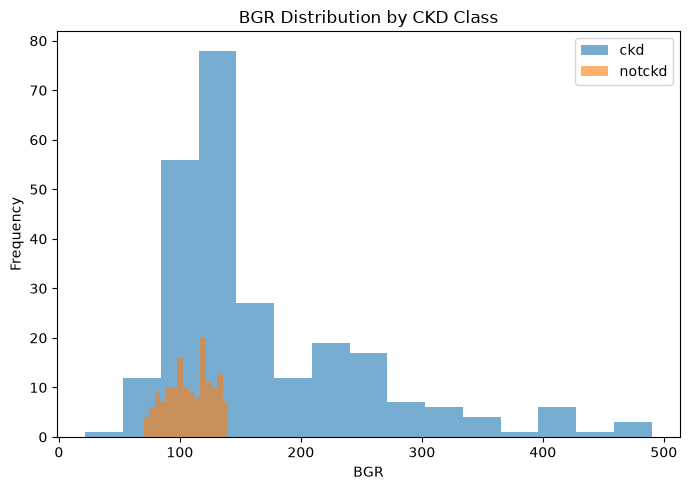

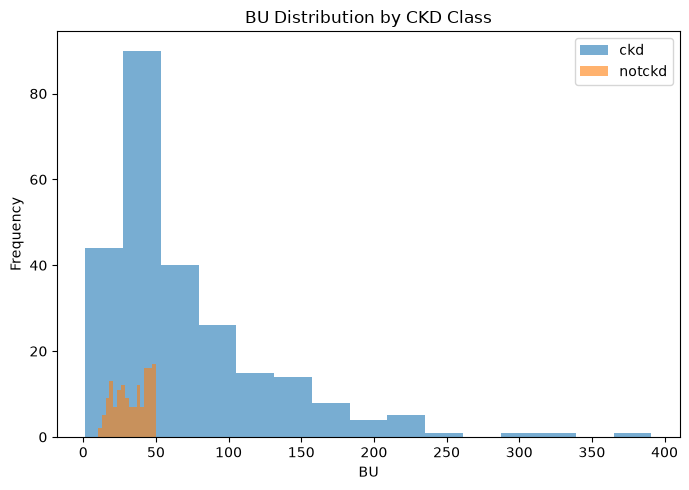

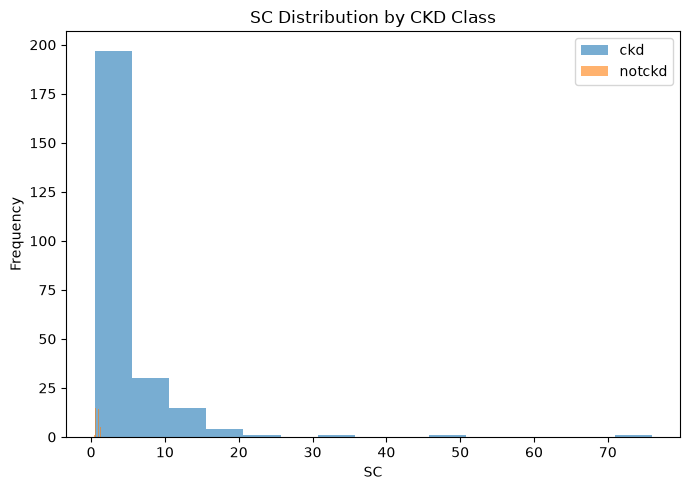

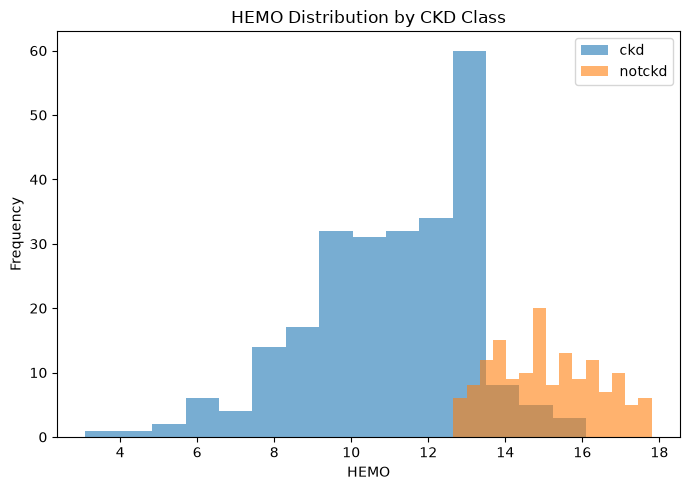

In [8]:
# Distribution plots for important numerical features
important_features = ["age", "bp", "bgr", "bu", "sc", "hemo"]

for col in important_features:
    plt.figure(figsize=(7, 5))

    for cls in ["ckd", "notckd"]:
        values = df.loc[df["class"] == cls, col].dropna()
        plt.hist(values, bins=15, alpha=0.6, label=cls)

    plt.title(f"{col.upper()} Distribution by CKD Class")
    plt.xlabel(col.upper())
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Distribution observations
- The CKD and Not CKD groups show different distribution patterns for several numerical variables.
- `bgr`, `bu`, and especially `sc` show visibly different patterns between the two classes.
- `hemo` also shows a noticeable shift between CKD and Not CKD groups.
- These differences suggest that numerical laboratory features may provide useful information for classification.
- Distribution plots show association/patterns; they do not by themselves prove causation.

## 5. Boxplots by Target Class

Boxplots help compare the median, spread and possible outliers of important numerical variables between CKD and Not CKD groups.

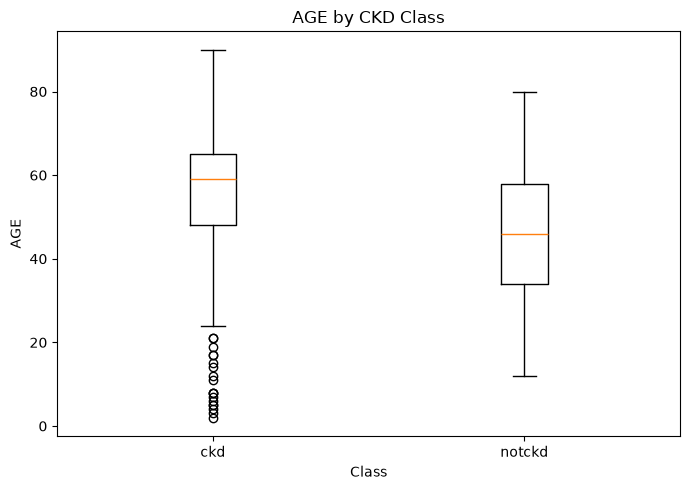

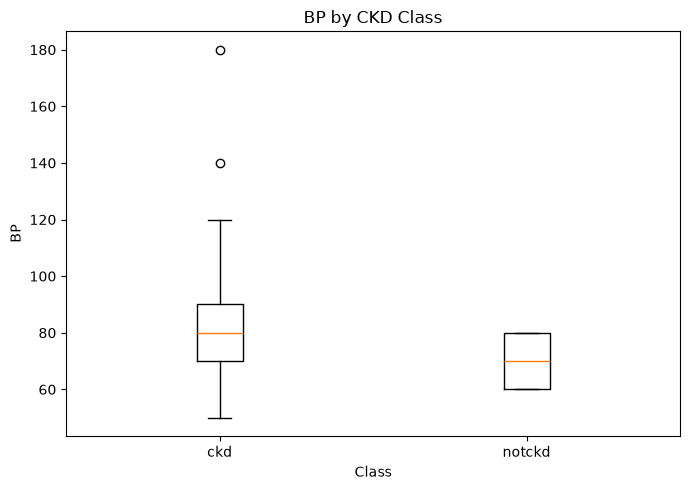

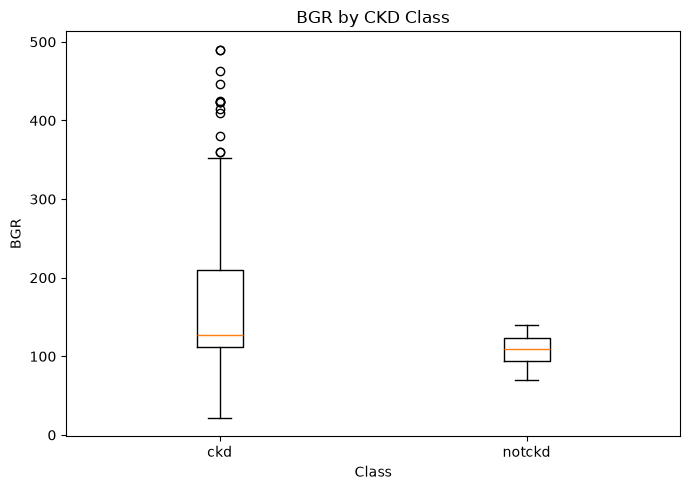

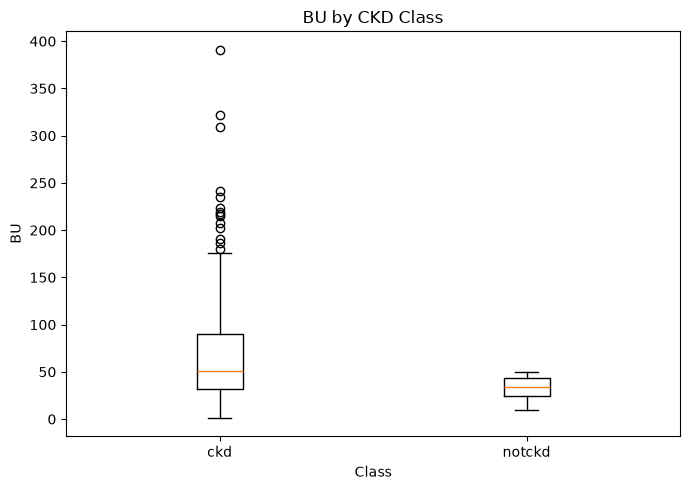

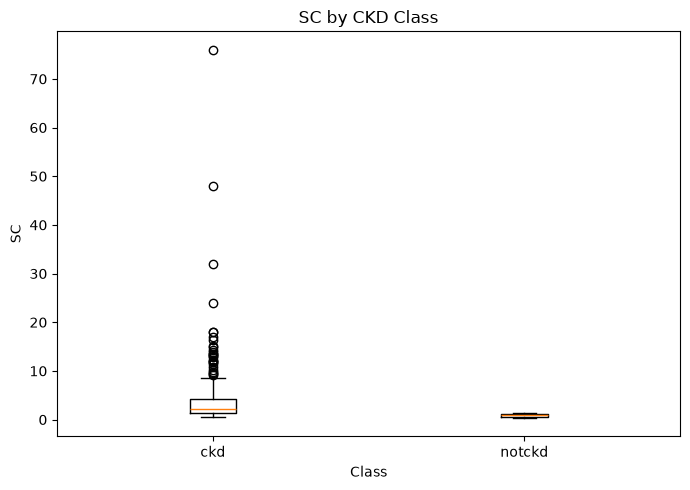

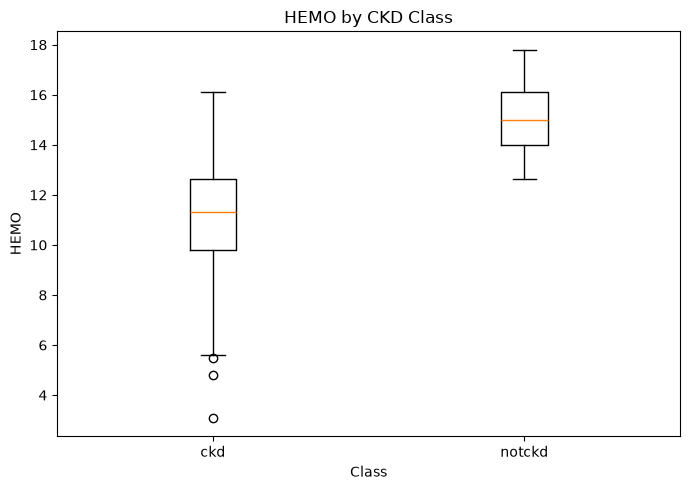

In [9]:
# Boxplots
for col in important_features:
    ckd_values = df.loc[df["class"] == "ckd", col].dropna()
    notckd_values = df.loc[df["class"] == "notckd", col].dropna()

    plt.figure(figsize=(7, 5))
    plt.boxplot([ckd_values, notckd_values],
                tick_labels=["ckd", "notckd"])
    plt.title(f"{col.upper()} by CKD Class")
    plt.xlabel("Class")
    plt.ylabel(col.upper())
    plt.tight_layout()
    plt.show()


### Boxplot observations
- Several variables have noticeably different medians between the two classes.
- CKD observations contain more extreme values for some laboratory variables, particularly `bgr`, `bu` and `sc`.
- Outliers should be investigated carefully rather than automatically removed because they may represent genuine patient measurements.

## 6. Categorical Feature Distributions

Categorical variables are compared across the CKD and Not CKD classes to identify useful patterns.

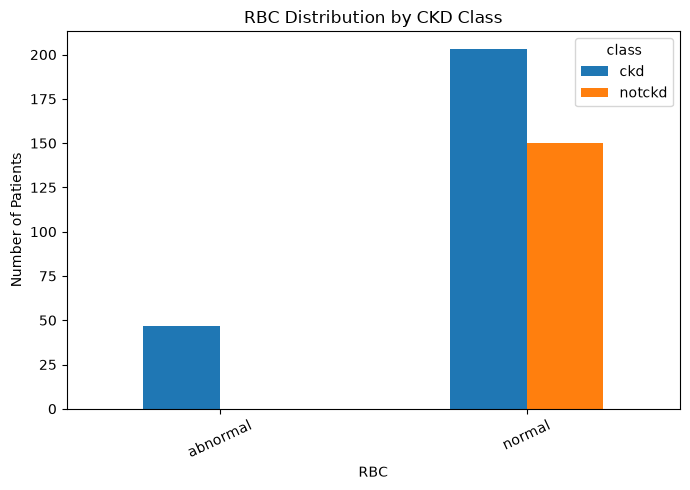

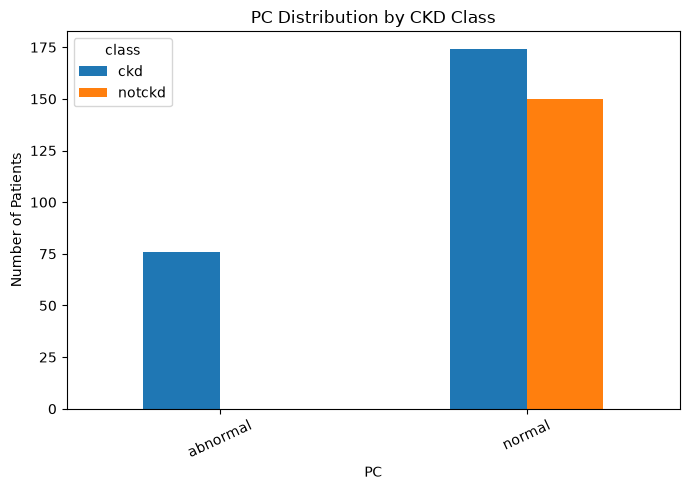

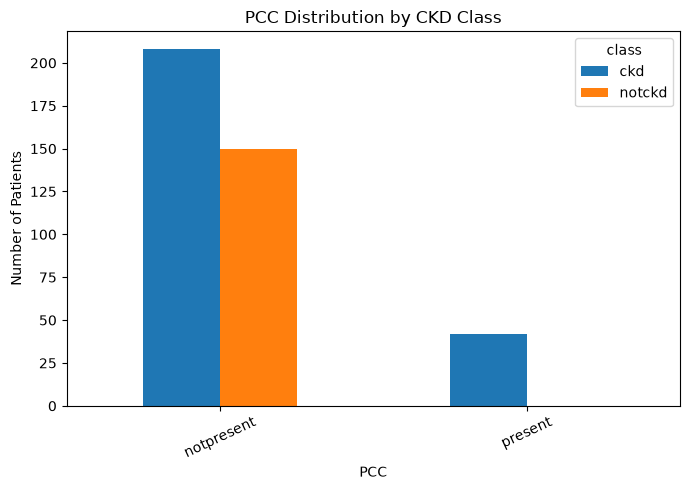

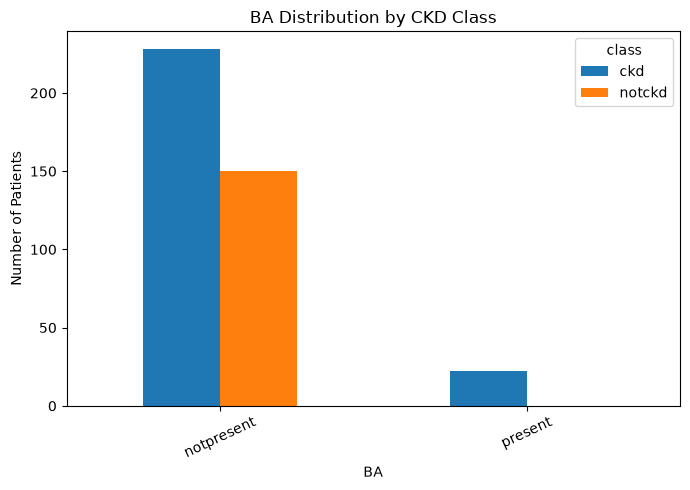

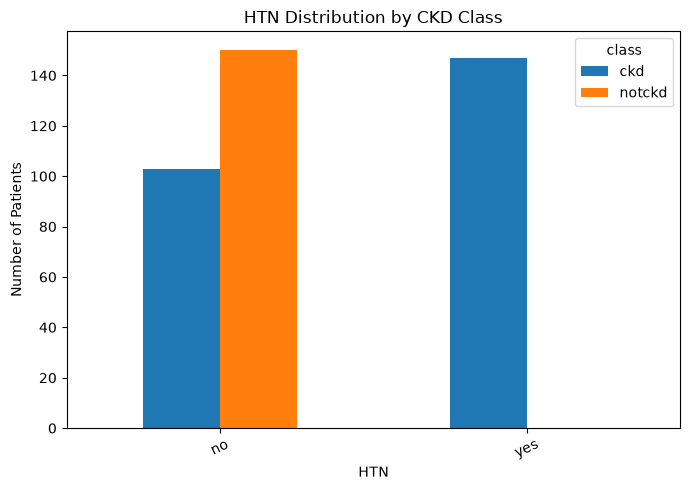

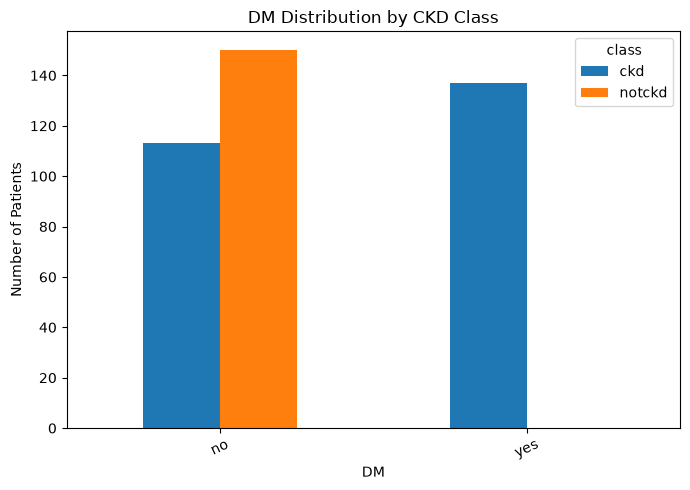

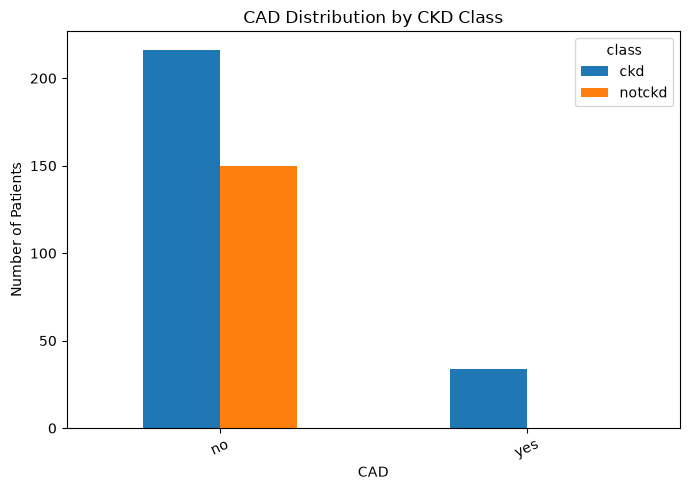

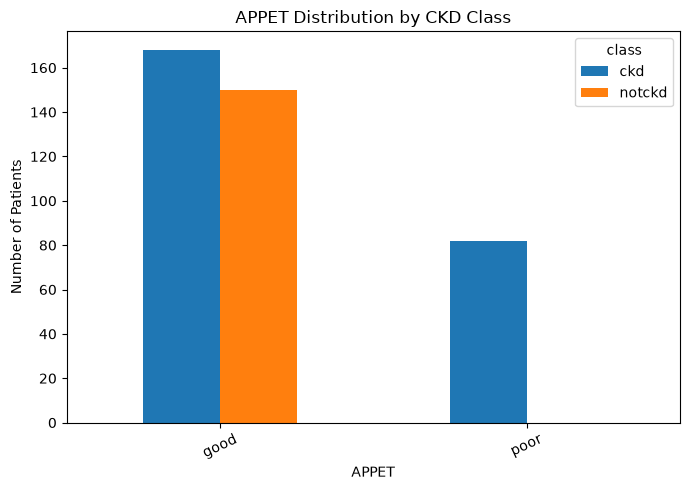

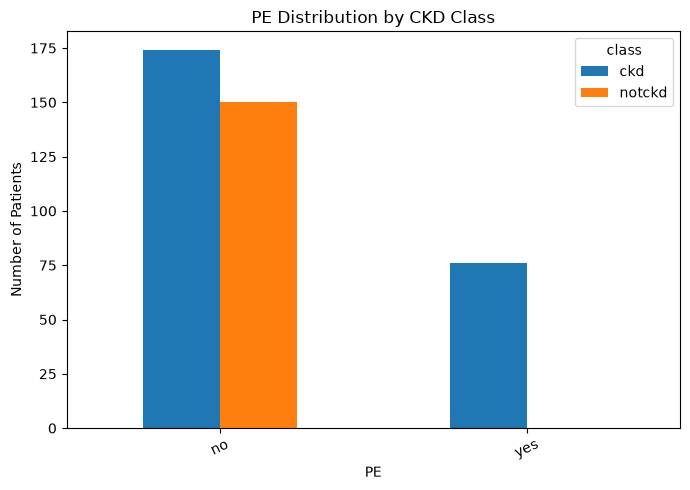

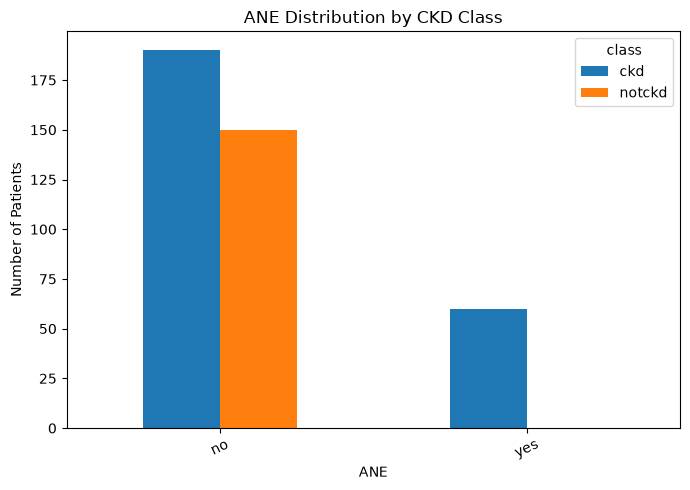

In [10]:
categorical_features = [
    "rbc", "pc", "pcc", "ba", "htn",
    "dm", "cad", "appet", "pe", "ane"
]

for col in categorical_features:
    table = pd.crosstab(df[col].fillna("missing"), df["class"])

    ax = table.plot(kind="bar", figsize=(7, 5))
    ax.set_title(f"{col.upper()} Distribution by CKD Class")
    ax.set_xlabel(col.upper())
    ax.set_ylabel("Number of Patients")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
    plt.close()


### Categorical observations
- `htn` and `dm` show clear differences in their distributions across CKD and Not CKD groups.
- `pe` and `ane` also show class-related differences.
- Features such as `rbc`, `pc`, `pcc` and `ba` provide additional categorical information that can be useful after encoding.
- Categorical patterns should be evaluated together with numerical features rather than using any single feature alone.

## 7. Correlation Analysis

Correlation analysis is applied to numerical features to identify the strength and direction of linear relationships and possible redundancy among variables.

In [11]:
# Correlation matrix
corr = df[numeric_cols].corr()

display(corr.round(3))


,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
age,1.000,0.136,-0.160,0.086,0.187,0.231,0.194,0.134,-0.086,0.049,-0.178,-0.213,0.094,-0.203
bp,0.136,1.000,-0.167,0.124,0.190,0.150,0.181,0.143,-0.101,0.064,-0.279,-0.289,0.022,-0.219
sg,-0.160,-0.167,1.000,-0.480,-0.292,-0.299,-0.245,-0.172,0.211,-0.053,0.491,0.496,-0.195,0.432
al,0.086,0.124,-0.480,1.000,0.288,0.293,0.347,0.161,-0.226,0.108,-0.474,-0.473,0.203,-0.405
su,0.187,0.190,-0.292,0.288,1.000,0.627,0.127,0.096,-0.052,0.177,-0.157,-0.181,0.157,-0.162
bgr,0.231,0.150,-0.299,0.293,0.627,1.000,0.119,0.069,-0.131,0.053,-0.254,-0.258,0.120,-0.214
bu,0.194,0.181,-0.245,0.347,0.127,0.119,1.000,0.582,-0.309,0.340,-0.542,-0.523,0.038,-0.465
sc,0.134,0.143,-0.172,0.161,0.096,0.069,0.582,1.000,-0.624,0.205,-0.342,-0.339,-0.010,-0.322
sod,-0.086,-0.101,0.211,-0.226,-0.052,-0.131,-0.309,-0.624,1.000,0.070,0.331,0.344,0.008,0.314
pot,0.049,0.064,-0.053,0.108,0.177,0.053,0.340,0.205,0.070,1.000,-0.096,-0.118,-0.076,-0.118


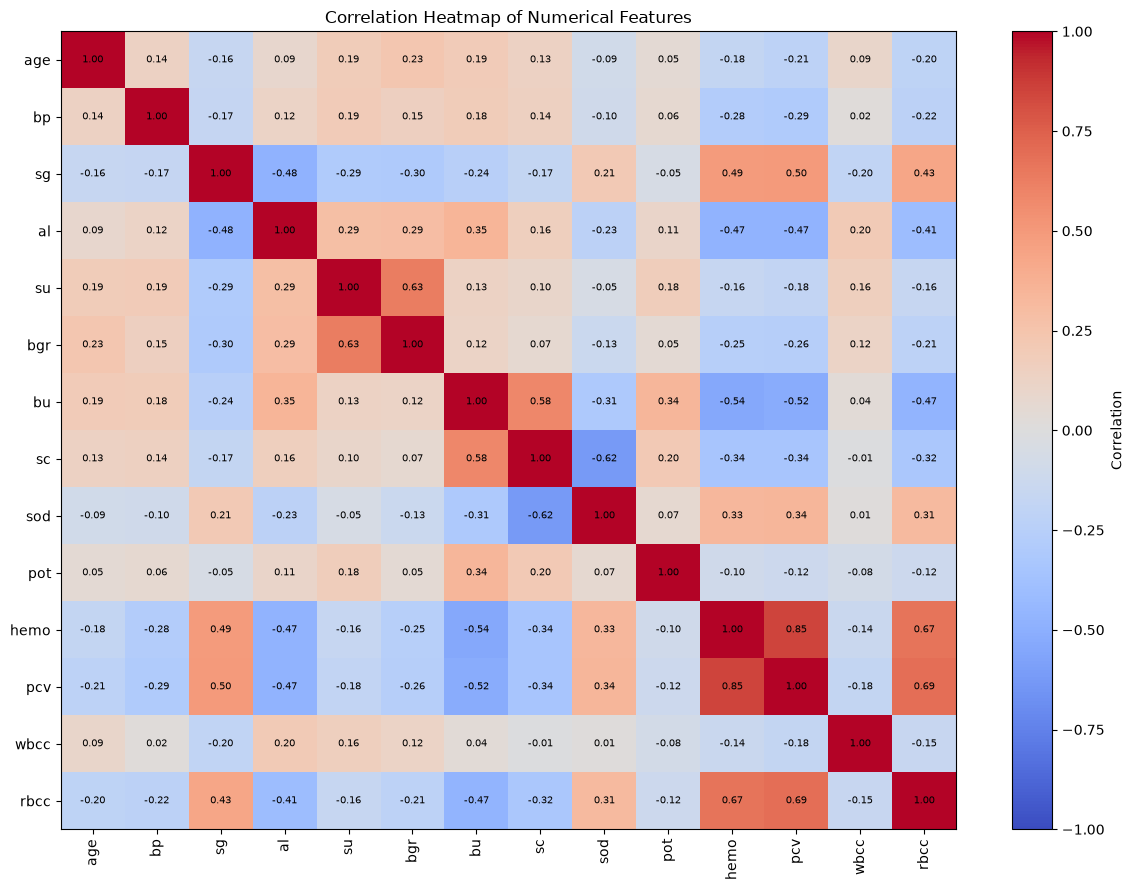

In [12]:
# Correlation heatmap
plt.figure(figsize=(12, 9))

plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap of Numerical Features")

for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.2f}",
                     ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()


In [13]:
# Find the strongest absolute correlations
pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack()

pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index)

print("Strongest numerical correlations:")
display(pairs.head(10).to_frame("correlation"))


Strongest numerical correlations:


correlation
hemo pcv      0.847490
pcv  rbcc     0.693473
hemo rbcc     0.667512
su   bgr      0.627002
sc   sod     -0.624036
bu   sc       0.581517
     hemo    -0.541635
     pcv     -0.523091
sg   pcv      0.496434
     hemo     0.490699

### Correlation observation
The correlation matrix helps identify variables that move together and may contain overlapping information. Highly correlated variables can be considered during feature selection, but correlation alone should not be used as the only criterion for removing a feature.

**Important:** correlation indicates association, not causation.

## 8. Class-wise Numerical Summary

Comparing numerical means between CKD and Not CKD provides another simple view of class differences.

In [14]:
class_means = df.groupby("class")[numeric_cols].mean().T.round(2)
display(class_means)


class,ckd,notckd
age,54.56,46.57
bp,79.64,71.47
sg,1.01,1.02
al,1.44,0.00
su,0.63,0.00
bgr,167.15,108.25
bu,70.81,33.17
sc,4.27,0.88
sod,135.25,141.61
pot,4.72,4.34


## 9. Overall EDA Observations / Inferences

### Key findings
1. The dataset contains **400 patient records and 25 columns**.
2. The target distribution contains **250 CKD records (62.5%)** and **150 Not CKD records (37.5%)**.
3. The processed dataset contains **0 missing values**, confirming that missing-value preprocessing was completed before this EDA stage.
4. Numerical variables have different ranges; feature scaling should be considered for scale-sensitive algorithms.
5. Important numerical variables such as `bgr`, `bu`, `sc` and `hemo` show noticeable distribution differences between CKD and Not CKD groups.
6. Categorical variables such as `htn`, `dm`, `pe` and `ane` show useful class-wise patterns.
7. The correlation analysis helps identify relationships and possible redundancy among numerical variables.
8. The EDA findings can be used to guide the **feature selection stage**.
9. EDA provides evidence of patterns in the dataset, but it does not replace clinical diagnosis or establish causal relationships.

## 10. EDA Conclusion

The exploratory analysis indicates that the CKD dataset contains meaningful differences between CKD and Not CKD patient groups across several numerical and categorical attributes. The results support proceeding to **Feature Engineering / Feature Selection**, followed by model building and evaluation.

### Next Step
➡️ **Feature Selection → Model Building → Hyperparameter Tuning → Model Evaluation → Model Comparison → Final Prediction**
